# IEEE-30 Wildfire-Aware Dispatch Optimization Validation

This notebook demonstrates the current `experiments/test` wildfire-aware predict-then-optimize workflow for GridFM using the corrected single-scenario extraction path.

## Decision Variables

The optimization keeps the current extended decision vector:

$$u = [u_{Pg}; u_{\delta}]$$

where `u_Pg` is active generation at controllable PV buses and `u_delta` is load shedding at PQ buses in MW.

## Current Objective

$$J(u)=\lambda_{gen} \sum (u_{Pg}-P_{g,base})^2 + \lambda_{shed} \sum u_{\delta} + \lambda_{wf} \cdot wildfire\_penalty(u)$$

The wildfire term is computed from branch loading using a soft activation threshold:

$$wildfire\_penalty = \sum_{\ell} w_\ell \max(0, loading_\ell - \eta_\ell)^2$$

with default `w_l = 1.0` and `eta_l = 0.7`.

## Presentation Notes

- the code now extracts one 30-bus graph from the batched IEEE-30 test loader
- the exact decision dimension is determined at runtime from that extracted graph
- the notebook should be presented as a wildfire-aware surrogate optimization prototype, not as a final AC-OPF-quality result


## Setup

In [1]:
import sys
import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve paths robustly whether the notebook is launched from repo root or experiments/test
cwd = Path.cwd().resolve()
if (cwd / "tests").exists() and (cwd / "experiments").exists():
    repo_root = cwd
    notebook_dir = repo_root / "experiments" / "test"
else:
    notebook_dir = cwd
    repo_root = notebook_dir.parent.parent

sys.path.insert(0, str(repo_root))

# Force deterministic behavior across full notebook reruns.
NOTEBOOK_SEED = 200
random.seed(NOTEBOOK_SEED)
np.random.seed(NOTEBOOK_SEED)
torch.manual_seed(NOTEBOOK_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(NOTEBOOK_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass

print(f"Notebook dir: {notebook_dir}")
print(f"Repo root: {repo_root}")
print(f"Python path: {sys.path[0]}")

from experiments.test import (
    ScenarioData,
    extract_scenario_from_batch,
    PVDispatchDecisionSpec,
    NeuralSolverWrapper,
    WildfirePenaltyEvaluator,
    DispatchOptimizationProblem,
    PipelineValidationHarness,
    load_gps_model,
)

from gridfm_graphkit.io.param_handler import NestedNamespace, load_model
from gridfm_graphkit.datasets.powergrid_datamodule import LitGridDataModule

import yaml

print("[OK] Imports successful")


Notebook dir: C:\Users\Caleb Lu\OneDrive\Documents\GT\Extracurriculars\Research\Grid FM\Experiments\GridFM-graphkit\experiments\test
Repo root: C:\Users\Caleb Lu\OneDrive\Documents\GT\Extracurriculars\Research\Grid FM\Experiments\GridFM-graphkit
Python path: C:\Users\Caleb Lu\OneDrive\Documents\GT\Extracurriculars\Research\Grid FM\Experiments\GridFM-graphkit


c:\Users\Caleb Lu\anaconda3\envs\gridfm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[OK] Imports successful


## 1. Load Test Data (IEEE-30)

In [2]:
# Load configuration
config_path = repo_root / "tests" / "config" / "gridFMv0.1_dummy.yaml"

with open(config_path, 'r', encoding='utf-8') as f:
    config_dict = yaml.safe_load(f)

args = NestedNamespace(**config_dict)

# Load datamodule - use test data directory
data_dir = repo_root / "tests" / "data"
datamodule = LitGridDataModule(args, data_dir=str(data_dir))
datamodule.setup(stage="test")

# Get one batched test sample
test_loader = datamodule.test_dataloader()[0]
batch = next(iter(test_loader))
ngraphs = int(batch.ptr.numel() - 1) if hasattr(batch, 'ptr') else 1

print("[OK] Loaded test batch")
print(f"  Num graphs in batch: {ngraphs}")
print(f"  Num nodes in batch: {batch.num_nodes}")
print(f"  Num edges in batch: {batch.num_edges}")
print(f"  PE shape: {batch.pe.shape}")


[OK] Loaded test batch
  Num graphs in batch: 2
  Num nodes in batch: 60
  Num edges in batch: 222
  PE shape: torch.Size([60, 20])


## 2. Extract Canonical Scenario

In [3]:
# Extract a single scenario from the batch
node_normalizer = datamodule.node_normalizers[0]
edge_normalizer = datamodule.edge_normalizers[0]

scenario = extract_scenario_from_batch(
    batch,
    node_normalizer,
    edge_normalizer,
    scenario_idx=0,
    scenario_id="IEEE-30-test",
)

print(f"[OK] Extracted scenario: {scenario.scenario_id}")
print(f"  Num buses: {scenario.num_buses}")
print(f"  PQ buses: {int(np.sum(scenario.PQ_mask))}")
print(f"  PV buses: {int(np.sum(scenario.PV_mask))}")
print(f"  REF buses: {int(np.sum(scenario.REF_mask))}")
print(f"  PE dimension: {scenario.pe.shape[1]}")


[OK] Extracted scenario: IEEE-30-test
  Num buses: 30
  PQ buses: 24
  PV buses: 5
  REF buses: 1
  PE dimension: 20


## 3. Decision Variable Specification

In [4]:
# Define decision variables
decision_spec = PVDispatchDecisionSpec(scenario)

print(f"✓ Decision specification created")
print(f"  Number of PV buses: {decision_spec.n_pv}")
print(f"  PV bus indices: {decision_spec.pv_bus_indices}")
print(f"  Baseline Pg at PV buses: {decision_spec.u_base}")
print(f"  Min bounds: {decision_spec.u_min}")
print(f"  Max bounds: {decision_spec.u_max}")

summary = decision_spec.get_summary()
print(f"\nDecision spec summary:")
for key, val in summary.items():
    print(f"  {key}: {val:.4f}")

✓ Decision specification created
  Number of PV buses: 5
  PV bus indices: [ 1  4  7 10 12]
  Baseline Pg at PV buses: [1.0029768e-06 3.7129796e-10 6.4983052e-10 1.4867026e-09 8.6981072e-10]
  Min bounds: [8.0238141e-07 2.9703837e-10 5.1986443e-10 1.1893622e-09 6.9584860e-10]
  Max bounds: [1.2035722e-06 4.4555756e-10 7.7979667e-10 1.7840432e-09 1.0437730e-09]

Decision spec summary:
  n_pv: 5.0000
  u_base_mean: 0.0000
  u_base_min: 0.0000
  u_base_max: 0.0000
  u_min_mean: 0.0000
  u_max_mean: 0.0000
  bound_range_mean: 0.0000


## 4. Load Neural Solver Models

In [5]:
# Load pretrained models
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# GNN model (v0.1)
model_gnn = load_model(args)
model_gnn_path = repo_root / "examples" / "models" / "GridFM_v0_1.pth"

if model_gnn_path.exists():
    checkpoint = torch.load(model_gnn_path, map_location=device, weights_only=False)
    state_dict = checkpoint['state_dict'] if isinstance(checkpoint, dict) and 'state_dict' in checkpoint else checkpoint
    if all(key.startswith('model.') for key in state_dict.keys()):
        state_dict = {key.removeprefix('model.'): value for key, value in state_dict.items()}
    model_gnn.load_state_dict(state_dict, strict=False)
    print(f"✓ Loaded GNN model from {model_gnn_path}")
else:
    print(f"⚠ GNN model not found at {model_gnn_path}")

# Create neural solver wrapper for GNN
solver_gnn = NeuralSolverWrapper(
    model_gnn,
    model_type="gnn",
    scenario=scenario,
    decision_spec=decision_spec,
    device=device,
)

print(f"✓ Created GNN solver wrapper")

Device: cpu
✓ Loaded GNN model from C:\Users\Caleb Lu\OneDrive\Documents\GT\Extracurriculars\Research\Grid FM\Experiments\GridFM-graphkit\examples\models\GridFM_v0_1.pth
✓ Created GNN solver wrapper


## 5. Create Wildfire Penalty Evaluator


In [6]:
# Create wildfire evaluator
wildfire_eval = WildfirePenaltyEvaluator(scenario, sn_mva=100.0)

print("[OK] Created wildfire evaluator")

baseline_wildfire = wildfire_eval.evaluate_baseline()
print("\nBaseline wildfire metrics:")
for key, val in baseline_wildfire.items():
    print(f"  {key}: {val}")


[OK] Created wildfire evaluator

Baseline wildfire metrics:
  wildfire_cost: 0.0
  total_penalty: 0.0
  n_active_risk_branches: 0
  n_overloaded_lines: 0
  max_loading: 0.532738362969474
  mean_loading: 0.0645877335658873
  max_branch_risk: 0.0


## 6. Full Pipeline Validation

In [7]:
# Run full validation
validation_report = PipelineValidationHarness.full_validation(
    scenario,
    decision_spec,
    solver_gnn,
    solver_gps=None,
    overload_eval=wildfire_eval,
)

validation_all_passed = validation_report.get("all_passed", False)
PipelineValidationHarness.print_validation_report(dict(validation_report), verbose=True)
print(f"\nValidation all_passed: {validation_all_passed}")
print("Note: a False result here is currently expected if surrogate voltage predictions are not physically reasonable.")


PIPELINE VALIDATION REPORT

[SCENARIO]
  Status: PASS (18/18)
    [OK] num_buses_consistent
    [OK] Pd_shape
    [OK] Qd_shape
    [OK] Pg_shape
    [OK] Qg_shape
    [OK] Vm_shape
    [OK] Va_shape
    [OK] PQ_shape
    [OK] PV_shape
    [OK] REF_shape
    [OK] bus_types_mutually_exclusive
    [OK] has_ref_bus
    [OK] G_shape
    [OK] B_shape
    [OK] pe_pe_dim
    [OK] mask_shape
    [OK] Pg_bounds_tight
    [OK] Pg_bounds_tight_2

[DECISION_SPEC]
  Status: PASS (6/6)
    [OK] n_pv_positive
    [OK] u_base_shape
    [OK] u_min_shape
    [OK] u_max_shape
    [OK] bounds_consistent
    [OK] u_base_within_bounds

[SOLVER_GNN]
  Status: FAIL (12/13)
    [OK] model_type_valid
    [OK] model_in_eval
    [OK] prediction_successful
    [OK] prediction_keys
    [OK] pred_Pd_shape
    [OK] pred_Qd_shape
    [OK] pred_Pg_shape
    [OK] pred_Qg_shape
    [OK] pred_Vm_shape
    [OK] pred_Va_shape
    [OK] predictions_finite
    [FAIL] Vm_reasonable_range
    [OK] baseline_validation_successful


## 7. Test Solver Predictions

In [8]:
# Test prediction on baseline
u_base = decision_spec.u_base
pred = solver_gnn.predict_state(u_base)

print("Baseline prediction (first 5 buses):")
print(f"  Pd: {pred['Pd'][:5]}")
print(f"  Qd: {pred['Qd'][:5]}")
print(f"  Pg: {pred['Pg'][:5]}")
print(f"  Qg: {pred['Qg'][:5]}")
print(f"  Vm: {pred['Vm'][:5]}")
print(f"  Va: {pred['Va'][:5]}")

# Compute error vs baseline
baseline_state = scenario.get_baseline_state()
print(f"\nPrediction errors (RMSE):")
for key in ['Pd', 'Qd', 'Pg', 'Qg', 'Vm', 'Va']:
    rmse = np.sqrt(np.mean((pred[key] - baseline_state[key]) ** 2))
    print(f"  {key}: {rmse:.4f}")

Baseline prediction (first 5 buses):
  Pd: [-11.111109    8.740865   -5.179888   -2.5127695  54.390602 ]
  Qd: [-2.8689375   8.858019    1.1955838   0.80002165 22.247183  ]
  Pg: [-11.111109    8.740865   -5.179888   -2.5127695  54.390602 ]
  Qg: [156.16994    -2.8198202  12.084993    1.2108      1.572462 ]
  Vm: [-0.5512509   8.15521     0.3196264  -0.05878022 29.701761  ]
  Va: [1.1210264 1.1232773 1.1501222 1.164945  1.0283009]

Prediction errors (RMSE):
  Pd: 4.7236
  Qd: 2.4410
  Pg: 34.5116
  Qg: 29.8549
  Vm: 9.1054
  Va: 10.3631


## 8. Create Wildfire-Aware Optimization Problem


In [9]:
# Create optimization problem
problem = DispatchOptimizationProblem(
    scenario=scenario,
    decision_spec=decision_spec,
    solver=solver_gnn,
    wildfire_eval=wildfire_eval,
    lambda_gen=1.0,
    lambda_shed=50.0,
    lambda_wf=10.0,
)

print("[OK] Created optimization problem")
print(f"  lambda_gen: {problem.lambda_gen}")
print(f"  lambda_shed: {problem.lambda_shed}")
print(f"  lambda_wf: {problem.lambda_wf}")


[OK] Created optimization problem
  lambda_gen: 1.0
  lambda_shed: 50.0
  lambda_wf: 10.0


## 9. Evaluate Objective at Baseline


In [10]:
# Evaluate objective at baseline
u_base = decision_spec.u_base
obj_base, details_base = problem.objective(u_base, return_details=True)

print("Objective at baseline dispatch:")
print(f"  Objective value: {obj_base:.4f}")
print(f"  Generator deviation cost: {details_base['generator_deviation_cost']:.4f}")
print(f"  Load shedding cost: {details_base['load_shedding_cost']:.4f}")
print(f"  Wildfire cost: {details_base['wildfire_cost']:.4f}")
print(f"  Active wildfire branches: {details_base['n_active_risk_branches']}")
print(f"  Max line loading: {details_base['max_loading']:.4f}")


Objective at baseline dispatch:
  Objective value: 3776.7288
  Generator deviation cost: 0.0000
  Load shedding cost: 0.0000
  Wildfire cost: 377.6729
  Active wildfire branches: 22
  Max line loading: 12.5802


## 10. Run Optimization

In [11]:
# Run optimization (with reduced iterations for demo)
print("Starting optimization...")
opt_result = problem.optimize(
    method="L-BFGS-B",
    maxiter=50,
    verbose=True,
)

print(f"\nOptimization result:")
print(f"  Success: {opt_result['success']}")
print(f"  Message: {opt_result['message']}")
print(f"  Iterations: {opt_result['n_iter']}")
print(f"  Final objective: {opt_result['obj_opt']:.4f}")
print(f"  Final cost: {opt_result['cost_opt']:.4f}")
print(f"  Final wildfire cost: {opt_result['wildfire_opt']:.4f}")

Starting optimization...

Optimization result:
  Success: True
  Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  Iterations: 0
  Final objective: 3776.7288
  Final cost: 0.0000
  Final wildfire cost: 377.6729


## 11. Compare Baseline vs. Optimized

In [12]:
# Compare baseline vs optimized
u_opt = opt_result['u_opt']
comparison = problem.compare_baseline_vs_optimized(u_opt)

print("\n" + "="*70)
print("BASELINE vs OPTIMIZED COMPARISON")
print("="*70)

print(f"\nBASELINE:")
for key, val in comparison['baseline'].items():
    if key != 'u':
        print(f"  {key}: {val:.4f}")

print(f"\nOPTIMIZED:")
for key, val in comparison['optimized'].items():
    if key != 'u':
        print(f"  {key}: {val:.4f}")

print(f"\nIMPROVEMENT:")
for key, val in comparison['improvement'].items():
    print(f"  {key}: {val:.4f}")

print("\n" + "="*70)


BASELINE vs OPTIMIZED COMPARISON

BASELINE:
  objective: 3776.7288
  generator_deviation_cost: 0.0000
  load_shedding_cost: 0.0000
  wildfire_cost: 377.6729
  n_active_risk_branches: 22.0000
  max_loading: 12.5802

OPTIMIZED:
  objective: 3776.7288
  generator_deviation_cost: 0.0000
  load_shedding_cost: 0.0000
  wildfire_cost: 377.6729
  n_active_risk_branches: 22.0000
  max_loading: 12.5802

IMPROVEMENT:
  objective: 0.0000
  objective_pct: 0.0000
  wildfire: 0.0000
  wildfire_pct: 0.0000



## 12. Visualize Optimization Progress

In [13]:
# Plot optimization history
history = opt_result['history']

if len(history['objective']) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    axes[0, 0].plot(history['objective'], 'b-', linewidth=2)
    axes[0, 0].set_xlabel('Iteration')
    axes[0, 0].set_ylabel('Objective Value')
    axes[0, 0].set_title('Total Objective')
    axes[0, 0].grid(True)
    
    axes[0, 1].plot(history['generator_deviation'], 'g-', linewidth=2)
    axes[0, 1].set_xlabel('Iteration')
    axes[0, 1].set_ylabel('Generator Deviation Cost')
    axes[0, 1].set_title('Generator Cost')
    axes[0, 1].grid(True)
    
    axes[1, 0].plot(history['wildfire'], 'r-', linewidth=2)
    axes[1, 0].set_xlabel('Iteration')
    axes[1, 0].set_ylabel('Wildfire Cost')
    axes[1, 0].set_title('Wildfire Component')
    axes[1, 0].grid(True)
    
    u_values = np.array(history['u'])
    for i in range(min(3, u_values.shape[1])):
        axes[1, 1].plot(u_values[:, i], label=f'Decision {i}')
    axes[1, 1].set_xlabel('Iteration')
    axes[1, 1].set_ylabel('Decision Value')
    axes[1, 1].set_title('Decision Trajectory')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.savefig('optimization_progress.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('[OK] Optimization progress plot saved as optimization_progress.png')
else:
    print('No optimization history to plot')


No optimization history to plot


## 13. Summary and Next Steps

## Phase 2: Load Shedding with Reduced Penalties

Now extending to load shedding with lower penalty weights to encourage iteration.

In [14]:
# Load GPS model (v0.2) - if available
model_gps_path = repo_root / "examples" / "models" / "GridFM_v0_2.pth"
has_gps = False

if model_gps_path.exists():
    model_gps, args_gps = load_gps_model(config_dict, repo_root=repo_root, device=device)
    has_gps = True
    print(f"[OK] Loaded GPS model from {model_gps_path}")
    print(f"[OK] GPS architecture: hidden_size={args_gps.model.hidden_size}, pe_dim={args_gps.model.pe_dim}, input_dim={args_gps.model.input_dim}, edge_dim={args_gps.model.edge_dim}, output_dim={args_gps.model.output_dim}")
else:
    print(f"[WARN] GPS model not found at {model_gps_path}")


[OK] Loaded GPS model from C:\Users\Caleb Lu\OneDrive\Documents\GT\Extracurriculars\Research\Grid FM\Experiments\GridFM-graphkit\examples\models\GridFM_v0_2.pth
[OK] GPS architecture: hidden_size=256, pe_dim=20, input_dim=9, edge_dim=2, output_dim=6


In [15]:
# Create extended dispatch spec with load shedding
from experiments.test import ExtendedDispatchSpec

decision_spec_extended = ExtendedDispatchSpec(scenario, max_shed_fraction=1.0)
summary = decision_spec_extended.get_summary()

print("[OK] Extended decision spec created:")
print(f"  - PV buses (Pg): {decision_spec_extended.n_pv}")
print(f"  - PQ buses (shedding): {decision_spec_extended.n_pq}")
print(f"  - Total decision dimension: {decision_spec_extended.n_total}")
print(f"  - Max total shedding: {summary['shed_max_shed_total_MW']:.1f} MW")
print(f"  - Max shed as % of PQ load: {summary['shed_max_shed_pct_of_pq']:.1f}%")


[OK] Extended decision spec created:
  - PV buses (Pg): 5
  - PQ buses (shedding): 24
  - Total decision dimension: 29
  - Max total shedding: 77.4 MW
  - Max shed as % of PQ load: 100.0%


In [16]:
# Create solvers with extended dispatch spec
solver_gnn_extended = NeuralSolverWrapper(model_gnn, 'gnn', scenario, decision_spec_extended, device=device)
print("[OK] Created GNN solver with extended dispatch spec")

if has_gps:
    solver_gps = NeuralSolverWrapper(model_gps, 'gps', scenario, decision_spec_extended, device=device)
    print("[OK] Created GPS solver with extended dispatch spec")


[OK] Created GNN solver with extended dispatch spec
[OK] Created GPS solver with extended dispatch spec


In [17]:
# GNN optimization with reduced penalties
print("\n" + "=" * 80)
print("GNN_v0.1 WITH LOAD SHEDDING (Reduced Penalties)")
print("=" * 80)
print("Penalty weights: lambda_gen=1.0, lambda_wf=10.0, lambda=0.01")

problem_gnn_shedding = DispatchOptimizationProblem(
    scenario, decision_spec_extended, solver_gnn_extended, wildfire_eval,
    lambda_gen=1.0,
    lambda_shed=50.0,
    lambda_wf=10.0,
)

result_gnn_shedding = problem_gnn_shedding.optimize(method='L-BFGS-B', maxiter=200, verbose=True)

print("\nOptimization completed:")
print(f"  Success: {result_gnn_shedding['success']}")
print(f"  Iterations: {result_gnn_shedding['n_iter']}")
print(f"  Message: {result_gnn_shedding['message']}")
print("\nObjective breakdown:")
print(f"  Cost deviation: {result_gnn_shedding['cost_opt']:.4f}")
print(f"  Shedding cost: {result_gnn_shedding['details'].get('cost_shedding', 0):.4f}")
print(f"  Wildfire cost: {result_gnn_shedding['wildfire_opt']:.4f}")
print(f"  TOTAL: {result_gnn_shedding['obj_opt']:.4f}")

u_opt_gnn_shed = result_gnn_shedding['u_opt']
Pg_change_gnn = np.sum(np.abs(u_opt_gnn_shed[:decision_spec_extended.n_pv] - decision_spec_extended.pv_spec.u_base))
shed_gnn = np.sum(u_opt_gnn_shed[decision_spec_extended.n_pv:])

print("\nDispatch changes:")
print(f"  Pg adjustment: {Pg_change_gnn:.4f} MW")
print(f"  Load shed: {shed_gnn:.4f} MW ({100 * decision_spec_extended.shed_spec.get_shed_fraction(u_opt_gnn_shed[decision_spec_extended.n_pv:]):.2f}% of PQ load)")



GNN_v0.1 WITH LOAD SHEDDING (Reduced Penalties)
Penalty weights: lambda_gen=1.0, lambda_wf=10.0, lambda=0.01

Optimization completed:
  Success: True
  Iterations: 0
  Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL

Objective breakdown:
  Cost deviation: 0.0000
  Shedding cost: 0.0000
  Wildfire cost: 377.4198
  TOTAL: 3774.1977

Dispatch changes:
  Pg adjustment: 0.0000 MW
  Load shed: 0.0000 MW (0.00% of PQ load)


In [18]:
# GPS optimization with reduced penalties (if available)
if has_gps:
    print("\n" + "=" * 80)
    print("GPS_v0.2 WITH LOAD SHEDDING (Reduced Penalties)")
    print("=" * 80)
    print("Penalty weights: lambda_gen=1.0, lambda_wf=10.0, lambda=0.01")

    problem_gps_shedding = DispatchOptimizationProblem(
        scenario, decision_spec_extended, solver_gps, wildfire_eval,
        lambda_gen=1.0,
        lambda_shed=50.0,
        lambda_wf=10.0,
    )

    result_gps_shedding = problem_gps_shedding.optimize(method='L-BFGS-B', maxiter=200, verbose=True)

    print("\nOptimization completed:")
    print(f"  Success: {result_gps_shedding['success']}")
    print(f"  Iterations: {result_gps_shedding['n_iter']}")
    print(f"  Message: {result_gps_shedding['message']}")
    print("\nObjective breakdown:")
    print(f"  Cost deviation: {result_gps_shedding['cost_opt']:.4f}")
    print(f"  Shedding cost: {result_gps_shedding['details'].get('cost_shedding', 0):.4f}")
    print(f"  Wildfire cost: {result_gps_shedding['wildfire_opt']:.4f}")
    print(f"  TOTAL: {result_gps_shedding['obj_opt']:.4f}")

    u_opt_gps_shed = result_gps_shedding['u_opt']
    Pg_change_gps = np.sum(np.abs(u_opt_gps_shed[:decision_spec_extended.n_pv] - decision_spec_extended.pv_spec.u_base))
    shed_gps = np.sum(u_opt_gps_shed[decision_spec_extended.n_pv:])

    print("\nDispatch changes:")
    print(f"  Pg adjustment: {Pg_change_gps:.4f} MW")
    print(f"  Load shed: {shed_gps:.4f} MW ({100 * decision_spec_extended.shed_spec.get_shed_fraction(u_opt_gps_shed[decision_spec_extended.n_pv:]):.2f}% of PQ load)")



GPS_v0.2 WITH LOAD SHEDDING (Reduced Penalties)
Penalty weights: lambda_gen=1.0, lambda_wf=10.0, lambda=0.01

Optimization completed:
  Success: True
  Iterations: 0
  Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL

Objective breakdown:
  Cost deviation: 0.0000
  Shedding cost: 0.0000
  Wildfire cost: 172.0423
  TOTAL: 1720.4228

Dispatch changes:
  Pg adjustment: 0.0000 MW
  Load shed: 0.0000 MW (0.00% of PQ load)


In [19]:
# Comparison Table: GNN vs GPS with Load Shedding
import pandas as pd

print("\n" + "=" * 90)
print("COMPARISON: GNN v0.1 vs GPS v0.2 with Wildfire Objective")
print("=" * 90)

comparison_data = {
    'Metric': [
        'Objective (Total)',
        'Cost Deviation',
        'Shedding Cost',
        'Wildfire Cost',
        'Iterations',
        'Pg Adjustment (MW)',
        'Load Shed (MW)',
        'Shed Fraction (%)'
    ],
    'GNN v0.1': [
        f"{result_gnn_shedding['obj_opt']:.2f}",
        f"{result_gnn_shedding['cost_opt']:.2f}",
        f"{result_gnn_shedding['details'].get('cost_shedding', 0):.2f}",
        f"{result_gnn_shedding['wildfire_opt']:.2f}",
        f"{result_gnn_shedding['n_iter']}",
        f"{Pg_change_gnn:.4f}",
        f"{shed_gnn:.4f}",
        f"{100 * decision_spec_extended.shed_spec.get_shed_fraction(u_opt_gnn_shed[decision_spec_extended.n_pv:]):.2f}%"
    ]
}

if has_gps:
    comparison_data['GPS v0.2'] = [
        f"{result_gps_shedding['obj_opt']:.2f}",
        f"{result_gps_shedding['cost_opt']:.2f}",
        f"{result_gps_shedding['details'].get('cost_shedding', 0):.2f}",
        f"{result_gps_shedding['wildfire_opt']:.2f}",
        f"{result_gps_shedding['n_iter']}",
        f"{Pg_change_gps:.4f}",
        f"{shed_gps:.4f}",
        f"{100 * decision_spec_extended.shed_spec.get_shed_fraction(u_opt_gps_shed[decision_spec_extended.n_pv:]):.2f}%"
    ]

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

if has_gps:
    print("\nInterpretation:")
    if result_gps_shedding['obj_opt'] < result_gnn_shedding['obj_opt']:
        print("  GPS produces the lower objective on this notebook run.")
    elif result_gps_shedding['obj_opt'] > result_gnn_shedding['obj_opt']:
        print("  GNN produces the lower objective on this notebook run.")
    else:
        print("  GNN and GPS produce matching objectives on this notebook run.")



COMPARISON: GNN v0.1 vs GPS v0.2 with Wildfire Objective
            Metric GNN v0.1 GPS v0.2
 Objective (Total)  3774.20  1720.42
    Cost Deviation     0.00     0.00
     Shedding Cost     0.00     0.00
     Wildfire Cost   377.42   172.04
        Iterations        0        0
Pg Adjustment (MW)   0.0000   0.0000
    Load Shed (MW)   0.0000   0.0000
 Shed Fraction (%)    0.00%    0.00%

Interpretation:
  GPS produces the lower objective on this notebook run.


In [20]:
# Shedding Breakdown Analysis
print("\n" + "="*80)
print("LOAD SHEDDING BREAKDOWN BY BUS")
print("="*80)

# Extract PQ bus shed amounts for both models
shed_vector_gnn = u_opt_gnn_shed[decision_spec_extended.n_pv:]
shed_vector_gps = u_opt_gps_shed[decision_spec_extended.n_pv:] if has_gps else None

# Get PQ bus indices
pq_bus_indices = np.where(scenario.PQ_mask > 0)[0]
print(f"\nTotal PQ buses: {len(pq_bus_indices)}")

# Top 10 buses by shedding (GNN)
shed_by_bus_gnn = [(bus_idx, scenario.Pd_base[bus_idx], shed_vector_gnn[i],
                     100*shed_vector_gnn[i]/scenario.Pd_base[bus_idx] if scenario.Pd_base[bus_idx] > 0 else 0)
                    for i, bus_idx in enumerate(pq_bus_indices) if shed_vector_gnn[i] > 1e-4]

if shed_by_bus_gnn:
    shed_by_bus_gnn.sort(key=lambda x: x[2], reverse=True)
    print(f"\nGNN: Top buses by shedding amount:")
    print(f"{'Bus Idx':>8} {'Base Pd (MW)':>14} {'Shed (MW)':>12} {'% Shed':>10}")
    print("-" * 50)
    for bus_idx, base_pd, shed, pct in shed_by_bus_gnn[:10]:
        print(f"{bus_idx:>8} {base_pd:>14.4f} {shed:>12.4f} {pct:>10.2f}%")
else:
    print("GNN: No significant shedding (all < 0.0001 MW)")

# Top 10 buses by shedding (GPS)
if has_gps and shed_vector_gps is not None:
    shed_by_bus_gps = [(bus_idx, scenario.Pd_base[bus_idx], shed_vector_gps[i],
                        100*shed_vector_gps[i]/scenario.Pd_base[bus_idx] if scenario.Pd_base[bus_idx] > 0 else 0)
                       for i, bus_idx in enumerate(pq_bus_indices) if shed_vector_gps[i] > 1e-4]
    
    if shed_by_bus_gps:
        shed_by_bus_gps.sort(key=lambda x: x[2], reverse=True)
        print(f"\nGPS: Top buses by shedding amount:")
        print(f"{'Bus Idx':>8} {'Base Pd (MW)':>14} {'Shed (MW)':>12} {'% Shed':>10}")
        print("-" * 50)
        for bus_idx, base_pd, shed, pct in shed_by_bus_gps[:10]:
            print(f"{bus_idx:>8} {base_pd:>14.4f} {shed:>12.4f} {pct:>10.2f}%")
    else:
        print("GPS: No significant shedding (all < 0.0001 MW)")


LOAD SHEDDING BREAKDOWN BY BUS

Total PQ buses: 24
GNN: No significant shedding (all < 0.0001 MW)
GPS: No significant shedding (all < 0.0001 MW)


## Summary: Current Interpretation

### What this notebook now represents

- It uses the corrected single-scenario extraction path.
- The optimizer now uses generator deviation cost, load shedding cost, and a wildfire-aware branch loading penalty.
- Thermal overload is no longer included as a separate objective term.

### What to look for when presenting results

- Compare the physical baseline wildfire cost from stored voltages against the surrogate wildfire cost from predicted voltages.
- Treat `validation_all_passed = False` as a model-quality signal, not a pipeline wiring failure.
- If optimization stops at 0 iterations, the surrogate is not providing a useful descent direction under the wildfire objective either.
- If GPS produces very large wildfire cost under the extended dispatch space, present that as instability.


In [21]:
print("\n" + "=" * 70)
print("NOTEBOOK SUMMARY")
print("=" * 70)

print("\n[OK] Current notebook workflow:")
print("  1. Load a batched IEEE-30 test sample")
print("  2. Extract a single graph from the batch")
print("  3. Build PV-only and extended dispatch decision spaces")
print("  4. Load pretrained GNN and optional GPS checkpoints")
print("  5. Evaluate wildfire risk metrics")
print("  6. Run Phase 1 and Phase 2 optimization experiments")
print("  7. Compare GNN and GPS behavior under the wildfire objective")

print("\nKey presentation points:")
print(f"  Validation all_passed: {validation_all_passed}")
print(f"  Phase 1 objective improvement: {comparison['improvement']['objective_pct']:.2f}%")
print(f"  Phase 1 wildfire reduction: {comparison['improvement']['wildfire_pct']:.2f}%")
print(f"  Extended decision dimension: {decision_spec_extended.n_total}")
if has_gps:
    print(f"  GNN extended objective: {result_gnn_shedding['obj_opt']:.4f}")
    print(f"  GPS extended objective: {result_gps_shedding['obj_opt']:.4f}")

print("\nCaution:")
print("  Present this notebook as a wildfire-aware surrogate optimization prototype, not as a final AC-OPF-quality result.")
print("  If you want fresh figures for a presentation, rerun the notebook so the outputs match the current wildfire objective.")
print("\n" + "=" * 70)



NOTEBOOK SUMMARY

[OK] Current notebook workflow:
  1. Load a batched IEEE-30 test sample
  2. Extract a single graph from the batch
  3. Build PV-only and extended dispatch decision spaces
  4. Load pretrained GNN and optional GPS checkpoints
  5. Evaluate wildfire risk metrics
  6. Run Phase 1 and Phase 2 optimization experiments
  7. Compare GNN and GPS behavior under the wildfire objective

Key presentation points:
  Validation all_passed: False
  Phase 1 objective improvement: 0.00%
  Phase 1 wildfire reduction: 0.00%
  Extended decision dimension: 29
  GNN extended objective: 3774.1977
  GPS extended objective: 1720.4228

Caution:
  Present this notebook as a wildfire-aware surrogate optimization prototype, not as a final AC-OPF-quality result.
  If you want fresh figures for a presentation, rerun the notebook so the outputs match the current wildfire objective.



## Perturbing Decision Variables

This section visualizes a 2D slice of the decision-variable space using:

- a uniform PV redispatch direction
- a proportional load-shedding direction across PQ buses

The contour shows the objective on that slice, and the labeled markers show several feasible decision-vector initializations projected onto the same plane.

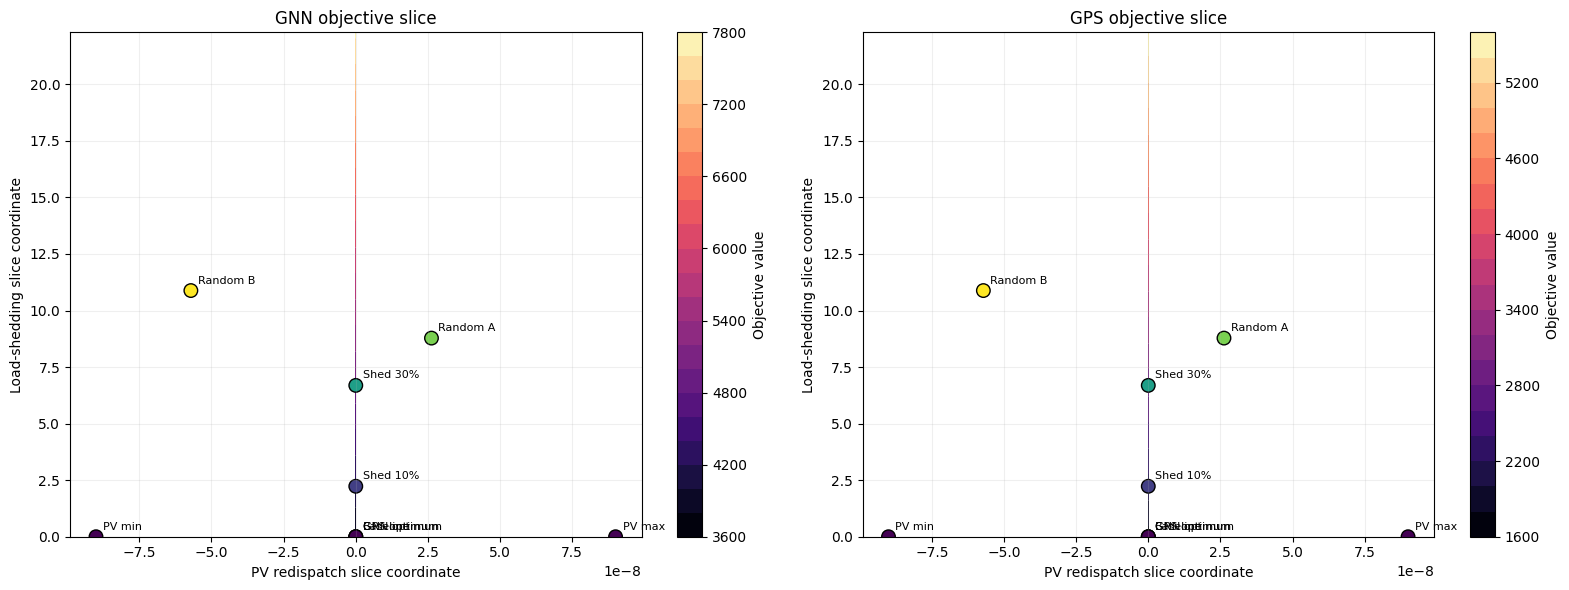

GNN initialization summary:


,Initialization,Objective,Wildfire Cost,Load Shedding Cost,Generator Cost,PV Slice Coordinate,Shed Slice Coordinate
0,Baseline,"3,774.20",377.42,0.0000,0.0000,0.0000,0.0000
1,PV min,"3,774.20",377.42,0.0000,0.0000,-0.0000,0.0000
2,PV max,"3,774.20",377.42,0.0000,0.0000,0.0000,0.0000
7,GNN optimum,"3,774.20",377.42,0.0000,0.0000,0.0000,0.0000
8,GPS optimum,"3,774.20",377.42,0.0000,0.0000,0.0000,0.0000
3,Shed 10%,"4,161.21",377.42,7.7404,0.0000,0.0000,2.2300
4,Shed 30%,"4,935.22",377.42,23.2212,0.0000,0.0000,6.6900
5,Random A,"5,430.07",377.41,33.1187,0.0000,0.0000,8.7816
6,Random B,"5,843.54",377.41,41.3884,0.0000,-0.0000,10.8831


GPS initialization summary:


,Initialization,Objective,Wildfire Cost,Load Shedding Cost,Generator Cost,PV Slice Coordinate,Shed Slice Coordinate
0,Baseline,"1,720.42",172.04,0.0000,0.0000,0.0000,0.0000
1,PV min,"1,720.42",172.04,0.0000,0.0000,-0.0000,0.0000
2,PV max,"1,720.42",172.04,0.0000,0.0000,0.0000,0.0000
7,GNN optimum,"1,720.42",172.04,0.0000,0.0000,0.0000,0.0000
8,GPS optimum,"1,720.42",172.04,0.0000,0.0000,0.0000,0.0000
3,Shed 10%,"2,106.14",171.91,7.7404,0.0000,0.0000,2.2300
4,Shed 30%,"2,877.71",171.67,23.2212,0.0000,0.0000,6.6900
5,Random A,"3,368.79",171.29,33.1187,0.0000,0.0000,8.7816
6,Random B,"3,781.49",171.21,41.3884,0.0000,-0.0000,10.8831


In [22]:
# Hyperplane slice of the objective under decision-variable perturbations
pv_dir = np.zeros(decision_spec_extended.n_total)
pv_dir[:decision_spec_extended.n_pv] = 1.0
pv_dir = pv_dir / np.linalg.norm(pv_dir)

shed_weights = decision_spec_extended.shed_spec.delta_max.copy()
shed_dir = np.zeros(decision_spec_extended.n_total)
if np.linalg.norm(shed_weights) > 0:
    shed_dir[decision_spec_extended.n_pv:] = shed_weights / np.linalg.norm(shed_weights)
else:
    shed_dir[decision_spec_extended.n_pv:] = 1.0
    shed_dir = shed_dir / np.linalg.norm(shed_dir)

u_base_ext = decision_spec_extended.u_base.copy()

def feasible_interval(direction):
    lower = []
    upper = []
    for idx, coeff in enumerate(direction):
        if abs(coeff) < 1e-12:
            continue
        lo = (decision_spec_extended.u_min[idx] - u_base_ext[idx]) / coeff
        hi = (decision_spec_extended.u_max[idx] - u_base_ext[idx]) / coeff
        lower.append(min(lo, hi))
        upper.append(max(lo, hi))
    return max(lower), min(upper)

pv_lo, pv_hi = feasible_interval(pv_dir)
shed_lo, shed_hi = feasible_interval(shed_dir)

pv_axis = np.linspace(pv_lo, pv_hi, 55)
shed_axis = np.linspace(shed_lo, shed_hi, 55)
PV_GRID, SHED_GRID = np.meshgrid(pv_axis, shed_axis)

def evaluate_plane(problem):
    surface = np.full_like(PV_GRID, np.nan, dtype=float)
    for i in range(PV_GRID.shape[0]):
        for j in range(PV_GRID.shape[1]):
            u_trial = u_base_ext + PV_GRID[i, j] * pv_dir + SHED_GRID[i, j] * shed_dir
            feasible, _ = decision_spec_extended.check_bounds(u_trial)
            if feasible:
                surface[i, j] = problem.objective(u_trial)
    return surface

init_rng = np.random.default_rng(200)
initializations_plane = {
    'Baseline': u_base_ext.copy(),
    'PV min': np.hstack([decision_spec_extended.pv_spec.u_min, decision_spec_extended.shed_spec.delta_base]),
    'PV max': np.hstack([decision_spec_extended.pv_spec.u_max, decision_spec_extended.shed_spec.delta_base]),
    'Shed 10%': decision_spec_extended.combine_decision_vector(
        decision_spec_extended.pv_spec.u_base,
        0.10 * decision_spec_extended.shed_spec.delta_max,
    ),
    'Shed 30%': decision_spec_extended.combine_decision_vector(
        decision_spec_extended.pv_spec.u_base,
        0.30 * decision_spec_extended.shed_spec.delta_max,
    ),
    'Random A': decision_spec_extended.u_min + init_rng.uniform(size=decision_spec_extended.n_total) * (decision_spec_extended.u_max - decision_spec_extended.u_min),
    'Random B': decision_spec_extended.u_min + init_rng.uniform(size=decision_spec_extended.n_total) * (decision_spec_extended.u_max - decision_spec_extended.u_min),
}

if 'result_gnn_shedding' in globals():
    initializations_plane['GNN optimum'] = result_gnn_shedding['u_opt']
if has_gps and 'result_gps_shedding' in globals():
    initializations_plane['GPS optimum'] = result_gps_shedding['u_opt']

def summarize_initializations(problem, labels):
    rows = []
    for label in labels:
        u = initializations_plane[label]
        obj, details = problem.objective(u, return_details=True)
        rows.append({
            'Initialization': label,
            'Objective': obj,
            'Wildfire Cost': details['wildfire_cost'],
            'Load Shedding Cost': details['load_shedding_cost'],
            'Generator Cost': details['generator_deviation_cost'],
            'PV Slice Coordinate': float(np.dot(u - u_base_ext, pv_dir)),
            'Shed Slice Coordinate': float(np.dot(u - u_base_ext, shed_dir)),
        })
    return pd.DataFrame(rows)

labels_to_plot = list(initializations_plane.keys())
gnn_surface = evaluate_plane(problem_gnn_shedding)
df_gnn_plane = summarize_initializations(problem_gnn_shedding, labels_to_plot)

fig, axes = plt.subplots(1, 2 if has_gps else 1, figsize=(16 if has_gps else 8, 6), squeeze=False)
axes = axes[0]

def draw_surface(ax, title, surface, df_points):
    contour = ax.contourf(PV_GRID, SHED_GRID, surface, levels=20, cmap='magma')
    ax.contour(PV_GRID, SHED_GRID, surface, levels=10, colors='white', linewidths=0.5, alpha=0.55)
    ax.scatter(df_points['PV Slice Coordinate'], df_points['Shed Slice Coordinate'], c=df_points['Objective'], cmap='viridis', s=95, edgecolor='black')
    for _, row in df_points.iterrows():
        ax.annotate(
            row['Initialization'],
            (row['PV Slice Coordinate'], row['Shed Slice Coordinate']),
            textcoords='offset points',
            xytext=(5, 5),
            fontsize=8,
        )
    ax.set_title(title)
    ax.set_xlabel('PV redispatch slice coordinate')
    ax.set_ylabel('Load-shedding slice coordinate')
    ax.grid(True, alpha=0.2)
    return contour

contour_gnn = draw_surface(axes[0], 'GNN objective slice', gnn_surface, df_gnn_plane)
plt.colorbar(contour_gnn, ax=axes[0], label='Objective value')

if has_gps:
    gps_surface = evaluate_plane(problem_gps_shedding)
    df_gps_plane = summarize_initializations(problem_gps_shedding, labels_to_plot)
    contour_gps = draw_surface(axes[1], 'GPS objective slice', gps_surface, df_gps_plane)
    plt.colorbar(contour_gps, ax=axes[1], label='Objective value')

plt.tight_layout()
plt.show()

print('GNN initialization summary:')
display(df_gnn_plane.sort_values('Objective').style.format({
    'Objective': '{:,.2f}',
    'Wildfire Cost': '{:,.2f}',
    'Load Shedding Cost': '{:,.4f}',
    'Generator Cost': '{:,.4f}',
    'PV Slice Coordinate': '{:.4f}',
    'Shed Slice Coordinate': '{:.4f}',
} ))

if has_gps:
    print('GPS initialization summary:')
    display(df_gps_plane.sort_values('Objective').style.format({
        'Objective': '{:,.2f}',
        'Wildfire Cost': '{:,.2f}',
        'Load Shedding Cost': '{:,.4f}',
        'Generator Cost': '{:,.4f}',
        'PV Slice Coordinate': '{:.4f}',
        'Shed Slice Coordinate': '{:.4f}',
    } ))
